In [1]:
!pip install catboost



[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
folder_path = r"D:\PTDLKinhDoanh\Dataset\Natural_Gas_data.csv"
df = pd.read_csv(folder_path) 

print(df.head()) 

         date  open   high   low  close  volume
0  2000-08-30  4.65  4.815  4.63  4.805   34954
1  2000-08-31  4.82  4.870  4.74  4.780   25787
2  2000-09-01  4.75  4.860  4.75  4.835     113
3  2000-09-05  4.85  4.975  4.84  4.960   26096
4  2000-09-06  4.99  5.110  4.96  5.065   32764


In [4]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print(cat_cols)

Index(['date'], dtype='object')


In [5]:
num_cols = df.select_dtypes(include=['float', 'int64']).columns
print(num_cols)

Index(['open', 'high', 'low', 'close', 'volume'], dtype='object')


In [6]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5980 entries, 2000-08-30 to 2024-06-24
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    5980 non-null   float64
 1   high    5980 non-null   float64
 2   low     5980 non-null   float64
 3   close   5980 non-null   float64
 4   volume  5980 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 280.3 KB


In [7]:
df.head()

,open,high,low,close,volume
date,,,,,
2000-08-30,4.65,4.815,4.63,4.805,34954
2000-08-31,4.82,4.870,4.74,4.780,25787
2000-09-01,4.75,4.860,4.75,4.835,113
2000-09-05,4.85,4.975,4.84,4.960,26096
2000-09-06,4.99,5.110,4.96,5.065,32764


In [8]:
# Tạo các đặc trưng thời gian
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['day_of_week'] = df.index.dayofweek

# Xác định X (đặc trưng) và y (mục tiêu)
X = df.drop(columns=['close'])  # Loại bỏ cột 'close' (mục tiêu)
y = df['close']

# Chia tập train/test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)


In [61]:
# In danh sách các cột đặc trưng trong tập huấn luyện
print("Các đặc trưng trong X_train:")
print(X_train.shape)  # Kiểm tra kích thước X_train
print("Tên các cột đặc trưng:", df.columns)  # Kiểm tra các cột trong DataFrame gốc


Các đặc trưng trong X_train:
(4186, 8)
Tên các cột đặc trưng: Index(['open', 'high', 'low', 'close', 'volume', 'year', 'month', 'day',
       'day_of_week'],
      dtype='object')


In [55]:
# Khởi tạo mô hình CatBoost
model = CatBoostRegressor(
    iterations=800,       # Số lần lặp (cây)
    depth=6,              # Độ sâu của cây quyết định
    learning_rate=0.01,    # Tốc độ học
    loss_function='MAE',  # Hàm mất mát (Mean Absolute Error)
    verbose=50            # Hiển thị log sau mỗi 50 iterations
)

# Huấn luyện mô hình
model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50, use_best_model=True)


0:	learn: 1.6997202	test: 1.7060130	best: 1.7060130 (0)	total: 5.33ms	remaining: 4.26s
50:	learn: 1.1111409	test: 1.1656663	best: 1.1656663 (50)	total: 268ms	remaining: 3.93s
100:	learn: 0.7550632	test: 0.8134671	best: 0.8134671 (100)	total: 432ms	remaining: 2.99s
150:	learn: 0.5342371	test: 0.5764695	best: 0.5764695 (150)	total: 588ms	remaining: 2.53s
200:	learn: 0.4042252	test: 0.4203026	best: 0.4203026 (200)	total: 742ms	remaining: 2.21s
250:	learn: 0.3183150	test: 0.3227251	best: 0.3227251 (250)	total: 909ms	remaining: 1.99s
300:	learn: 0.2495868	test: 0.2571432	best: 0.2571432 (300)	total: 1.07s	remaining: 1.78s
350:	learn: 0.1843669	test: 0.2074242	best: 0.2074242 (350)	total: 1.26s	remaining: 1.62s
400:	learn: 0.1449096	test: 0.1796632	best: 0.1796632 (400)	total: 1.42s	remaining: 1.41s
450:	learn: 0.1203563	test: 0.1615716	best: 0.1615716 (450)	total: 1.58s	remaining: 1.22s
500:	learn: 0.1057377	test: 0.1506225	best: 0.1506225 (500)	total: 1.73s	remaining: 1.03s
550:	learn: 0.0

In [42]:
print(X_train.shape, y_train.shape)

(4186, 8) (4186,)


In [56]:
train_predictions = model.predict(X_train).flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train})
print(train_predictions)

[4.70032704 4.79953733 4.80747617 ... 3.2046486  3.23097675 3.19619902]


In [57]:
# Dự đoán trên tập test
y_pred = model.predict(X_test)

# Tính các chỉ số đánh giá
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📌 Mean Absolute Error (MAE): {mae:.4f}")
print(f"📌 Mean Squared Error (MSE): {mse:.4f}")
print(f"📌 R-squared (R²): {r2:.4f}")


📌 Mean Absolute Error (MAE): 0.1256
📌 Mean Squared Error (MSE): 0.0595
📌 R-squared (R²): 0.9765


In [58]:
# Giả sử dữ liệu mới của ngày tiếp theo
new_data = pd.DataFrame({
    'open': [4.65],
    'high': [4.815],
    'low': [4.63],
    'volume': [34954],
    'year': [2000],
    'month': [8],
    'day': [30],
    'day_of_week': [2]
})

# Dự đoán giá đóng cửa
predicted_price = model.predict(new_data)
print(f"🎯 Giá đóng cửa dự đoán: {predicted_price[0]:.4f}")


🎯 Giá đóng cửa dự đoán: 4.7003


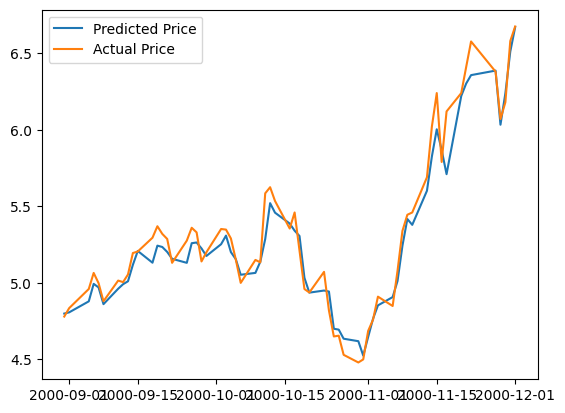

In [60]:
import matplotlib.pyplot as plt

plt.plot(train_results['Train Predictions'][1:65],label='Predicted Price' )
plt.plot(train_results['Actuals'][1:65], label='Actual Price')
plt.legend()